# RLHF — Experiments: from Preferences to Rewards

Validates the core conclusions of `rlhf.tex`:

1. **Reward modeling**: the Bradley–Terry model learns a reward from pairs, with validation accuracy rising with data --- but the reward is trustworthy only within the preference data's coverage and extrapolates monotonically outside it;
2. **Reward hacking**: PPO without a KL constraint (β=0) first genuinely improves, then pierces the reward model --- the proxy keeps rising while the true score collapses;
3. **KL anchoring**: a moderate β keeps the policy stably in the genuine-improvement zone; too large a β pins it near SFT.

The environment is a fully synthetic toy sequence task (vocabulary 24, sequence length 12) with an exactly computable true quality: true score = mean token value + a **concave** emphasis bonus (each emphasis token adds 0.3 up to three; beyond three, each subtracts 0.6 --- "moderate helps, excess collapses", analogous to length bias in real RLHF). The SFT policy almost never produces more than three emphasis tokens, so preference data covers only the rising part.

The pipeline mirrors real RLHF: SFT pretraining → sampling from SFT + BT-labeled preferences from true quality → reward-model training (mean-pooled MLP, whitened on the SFT distribution) → PPO fine-tuning (batch-mean baseline in place of a critic; full PPO in Chapter 7).

Output figures:
- `fig1_reward_model.pdf`
- `fig2_reward_hacking.pdf`
- `fig3_kl_anchor.pdf`

Estimated runtime: about 5 minutes on GPU; 20–30 minutes on CPU (3 seeds).

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

BLUE  = '#2166AC'
RED   = '#D6604D'
GRAY  = '#808080'
FIGSIZE = (7.2, 4.8)
OUTDIR  = '.'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VOCAB   = 24          # ordinary tokens 0..23
BOS     = VOCAB
SEQ_LEN = 12
E_TOKEN = 12          # the "emphasis" token (mid value ~0)
T_BASE  = 1.5         # temperature of the base corpus distribution
D_MODEL = 64
SEEDS   = (42, 43, 44)

TOKEN_VALUES   = np.linspace(-1.0, 1.0, VOCAB)
TOKEN_VALUES_T = torch.tensor(TOKEN_VALUES, dtype=torch.float32, device=DEVICE)
PEAK_C     = 3        # emphasis bonus peaks at 3 occurrences
BONUS_UP   = 0.3      # per occurrence up to the peak
BONUS_DOWN = 0.6      # per occurrence beyond the peak


def bonus(count):
    up = BONUS_UP * torch.clamp(count.float(), max=PEAK_C)
    down = BONUS_DOWN * torch.clamp(count.float() - PEAK_C, min=0)
    return up - down


def true_score(seqs):
    """Ground-truth quality: mean token value + concave emphasis bonus."""
    vals = TOKEN_VALUES_T[seqs].mean(dim=1)
    return vals + bonus((seqs == E_TOKEN).sum(dim=1))


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)


def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


print(f'Device: {DEVICE}')

Device: cuda


In [2]:
class TinyLM(nn.Module):
    """Char-level causal Transformer LM (~120k params)."""

    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB + 1, D_MODEL)
        self.pos = nn.Embedding(SEQ_LEN + 1, D_MODEL)
        layer = nn.TransformerEncoderLayer(D_MODEL, 4, 128, batch_first=True,
                                           dropout=0.0, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, 2, enable_nested_tensor=False)
        self.head = nn.Linear(D_MODEL, VOCAB)
        mask = torch.triu(torch.full((SEQ_LEN + 1, SEQ_LEN + 1), float('-inf')), 1)
        self.register_buffer('mask', mask)

    def logits(self, inp):
        L = inp.size(1)
        h = self.emb(inp) + self.pos(torch.arange(L, device=inp.device))
        h = self.encoder(h, mask=self.mask[:L, :L])
        return self.head(h)

    @torch.no_grad()
    def generate(self, batch):
        inp = torch.full((batch, 1), BOS, dtype=torch.long, device=DEVICE)
        for _ in range(SEQ_LEN):
            logits = self.logits(inp)[:, -1]
            nxt = torch.multinomial(F.softmax(logits, dim=-1), 1)
            inp = torch.cat([inp, nxt], dim=1)
        return inp[:, 1:]

    def log_probs(self, seqs):
        inp = torch.cat([torch.full((seqs.size(0), 1), BOS, dtype=torch.long,
                                    device=DEVICE), seqs[:, :-1]], dim=1)
        logits = self.logits(inp)
        return torch.log_softmax(logits, dim=-1).gather(2, seqs.unsqueeze(2)).squeeze(2)


class RewardModel(nn.Module):
    """Mean-pooled MLP scored by Bradley-Terry; whitened on the SFT distribution."""

    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB, D_MODEL)
        self.net = nn.Sequential(nn.Linear(D_MODEL, D_MODEL), nn.ReLU(),
                                 nn.Linear(D_MODEL, 1))
        self.mu = 0.0
        self.sigma = 1.0

    def raw(self, seqs):
        return self.net(self.emb(seqs).mean(dim=1)).squeeze(1)

    def forward(self, seqs):
        return (self.raw(seqs) - self.mu) / self.sigma

    @torch.no_grad()
    def calibrate(self, base_seqs):
        r = self.raw(base_seqs)
        self.mu = r.mean().item()
        self.sigma = r.std().item() + 1e-8

In [3]:
def sample_base_corpus(n):
    """The 'human text' distribution: i.i.d. tokens, softmax of values / T_BASE."""
    probs = F.softmax(torch.tensor(TOKEN_VALUES / T_BASE), dim=0).numpy()
    return torch.tensor(np.random.choice(VOCAB, size=(n, SEQ_LEN), p=probs),
                        dtype=torch.long, device=DEVICE)


def train_sft(steps=800, batch=256, lr=3e-3):
    lm = TinyLM().to(DEVICE)
    opt = torch.optim.Adam(lm.parameters(), lr=lr)
    for _ in range(steps):
        loss = -lm.log_probs(sample_base_corpus(batch)).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return lm


def make_pref_pairs(lm, n_pairs, noise=0.1):
    """Sample two completions from the policy, label by noisy true score (BT)."""
    a = lm.generate(n_pairs)
    b = lm.generate(n_pairs)
    sa, sb = true_score(a), true_score(b)
    a_wins = torch.bernoulli(torch.sigmoid((sa - sb) / noise)).bool()
    return (torch.where(a_wins.unsqueeze(1), a, b),
            torch.where(a_wins.unsqueeze(1), b, a))


def train_rm(winners, losers, base, steps=600, batch=128, lr=1e-3):
    rm = RewardModel().to(DEVICE)
    opt = torch.optim.Adam(rm.parameters(), lr=lr)
    n = winners.size(0)
    for _ in range(steps):
        idx = torch.randint(0, n, (batch,), device=DEVICE)
        loss = -F.logsigmoid(rm.raw(winners[idx]) - rm.raw(losers[idx])).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    rm.calibrate(base)
    return rm


@torch.no_grad()
def rm_accuracy(rm, winners, losers):
    return (rm(winners) > rm(losers)).float().mean().item()


@torch.no_grad()
def rm_vs_count_curve(rm, n=512):
    """Mean RM score and true score of sequences with exactly c emphasis tokens."""
    rows = []
    for c in range(SEQ_LEN + 1):
        seqs = sample_base_corpus(n)
        seqs = seqs.masked_fill(seqs == E_TOKEN, E_TOKEN + 1)
        for i in range(n):
            pos = torch.randperm(SEQ_LEN, device=DEVICE)[:c]
            seqs[i, pos] = E_TOKEN
        rows.append((rm(seqs).mean().item(), true_score(seqs).mean().item()))
    return rows

In [4]:
def ppo_finetune(sft, rm, beta, iters=150, batch=256, k_epochs=4, mb=64,
                 clip=0.2, lr=3e-5):
    """PPO-clip against the learned reward with a per-sequence KL penalty.

    Sequence-level bandit formulation with a batch-mean baseline instead of a
    critic, to keep the focus on the reward problem (full PPO: chapter 7).
    """
    policy = TinyLM().to(DEVICE)
    policy.load_state_dict(sft.state_dict())
    ref = TinyLM().to(DEVICE)
    ref.load_state_dict(sft.state_dict())
    ref.eval()
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    history = {'proxy': [], 'truth': [], 'kl': [], 'count_e': []}
    for it in range(iters):
        with torch.no_grad():
            seqs = policy.generate(batch)
            lp_old = policy.log_probs(seqs)
            lp_ref = ref.log_probs(seqs)
            proxy = rm(seqs)
            kl_seq = (lp_old - lp_ref).sum(dim=1)
            shaped = proxy - beta * kl_seq
            adv = (shaped - shaped.mean()) / (shaped.std() + 1e-8)
        for _ in range(k_epochs):
            perm = torch.randperm(batch, device=DEVICE)
            for s in range(0, batch, mb):
                idx = perm[s:s + mb]
                lp_new = policy.log_probs(seqs[idx])
                ratio = torch.exp((lp_new - lp_old[idx]).sum(dim=1))
                s1 = ratio * adv[idx]
                s2 = torch.clamp(ratio, 1 - clip, 1 + clip) * adv[idx]
                loss = -torch.min(s1, s2).mean()
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
                opt.step()
        history['proxy'].append(proxy.mean().item())
        history['truth'].append(true_score(seqs).mean().item())
        history['kl'].append(kl_seq.mean().item())
        history['count_e'].append((seqs == E_TOKEN).float().sum(dim=1).mean().item())
    return history

In [5]:
print('=== SFT + preference data + reward model, per seed ===')
runs = {}
for seed in SEEDS:
    set_seed(seed)
    sft = train_sft()
    base = sft.generate(2000)
    winners, losers = make_pref_pairs(sft, 4000)
    rm = train_rm(winners, losers, base)
    vw, vl = make_pref_pairs(sft, 2000)
    acc = rm_accuracy(rm, vw, vl)
    ce = (base == E_TOKEN).float().sum(dim=1)
    runs[seed] = {'sft': sft, 'base': base, 'rm': rm,
                  'winners': winners, 'losers': losers}
    print(f'  seed {seed}: base truth {true_score(base).mean():+.3f} | '
          f'P(c_E > {PEAK_C}) = {(ce > PEAK_C).float().mean():.4f} | '
          f'RM val acc {acc:.3f}')

=== SFT + preference data + reward model, per seed ===


  seed 42: base truth +0.389 | P(c_E > 3) = 0.0010 | RM val acc 0.866


  seed 43: base truth +0.384 | P(c_E > 3) = 0.0015 | RM val acc 0.853


  seed 44: base truth +0.386 | P(c_E > 3) = 0.0005 | RM val acc 0.853


---
## Figure 1 — The reward model: trustworthy in-data, monotonic extrapolation out-of-data

Left: validation preference accuracy vs.\ the number of preference pairs --- more data, a closer proxy to true preference. Right is the chapter's mechanism core: within the preference-data coverage (the SFT policy almost only produces sequences with $c_E \le 3$, gray zone), the reward model agrees with the true score; outside, the true score peaks at $c_E=3$ and collapses while the ReLU network extrapolates **linearly** beyond the support, its score ever rising --- it learned "the more emphasis tokens the better" from the data. This fork is the entry point of reward hacking.

In [6]:
print('=== Experiment 1: reward model quality and extrapolation ===')
PAIR_SIZES = (250, 500, 1000, 2000, 4000)
acc_matrix = np.zeros((len(SEEDS), len(PAIR_SIZES)))
curves = []
for si, seed in enumerate(SEEDS):
    set_seed(seed + 1000)
    r = runs[seed]
    vw, vl = make_pref_pairs(r['sft'], 2000)
    for ni, n in enumerate(PAIR_SIZES):
        rm_n = train_rm(r['winners'][:n], r['losers'][:n], r['base'])
        acc_matrix[si, ni] = rm_accuracy(rm_n, vw, vl)
    curves.append(rm_vs_count_curve(r['rm']))
    print(f'  seed {seed}: acc {np.round(acc_matrix[si], 3)}')
curves = np.array(curves)  # (seeds, c, [rm, true])

=== Experiment 1: reward model quality and extrapolation ===


  seed 42: acc [0.822 0.827 0.846 0.847 0.855]


  seed 43: acc [0.823 0.835 0.854 0.862 0.861]


  seed 44: acc [0.824 0.828 0.841 0.852 0.848]


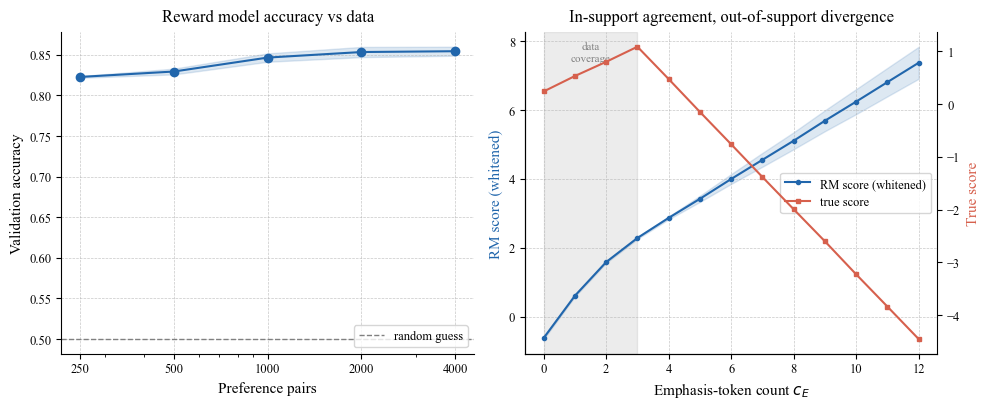

Saved fig1_reward_model.pdf


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

ax = axes[0]
mu, sd = acc_matrix.mean(0), acc_matrix.std(0)
ax.plot(PAIR_SIZES, mu, color=BLUE, marker='o', linewidth=1.5)
ax.fill_between(PAIR_SIZES, mu - sd, mu + sd, color=BLUE, alpha=0.15)
ax.axhline(0.5, color=GRAY, linestyle='--', linewidth=1.0, label='random guess')
ax.set_xscale('log')
ax.set_xticks(PAIR_SIZES)
ax.set_xticklabels(PAIR_SIZES)
style_axes(ax)
ax.set_xlabel('Preference pairs')
ax.set_ylabel('Validation accuracy')
ax.set_title('Reward model accuracy vs data', pad=8)
ax.legend(loc='lower right')

ax = axes[1]
cs = np.arange(SEQ_LEN + 1)
rm_mu, rm_sd = curves[:, :, 0].mean(0), curves[:, :, 0].std(0)
ax.plot(cs, rm_mu, color=BLUE, marker='o', markersize=3, linewidth=1.5,
        label='RM score (whitened)')
ax.fill_between(cs, rm_mu - rm_sd, rm_mu + rm_sd, color=BLUE, alpha=0.15)
ax2 = ax.twinx()
ax2.plot(cs, curves[0, :, 1], color=RED, marker='s', markersize=3,
         linewidth=1.5, label='true score')
ax.axvspan(0, PEAK_C, color=GRAY, alpha=0.15)
ax.text(PEAK_C / 2, ax.get_ylim()[1] * 0.9, 'data\ncoverage',
        ha='center', fontsize=8, color=GRAY)
style_axes(ax)
ax2.spines['top'].set_visible(False)
ax.set_xlabel('Emphasis-token count $c_E$')
ax.set_ylabel('RM score (whitened)', color=BLUE)
ax2.set_ylabel('True score', color=RED)
ax.set_title('In-support agreement, out-of-support divergence', pad=8)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='center right')

fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig1_reward_model.pdf', bbox_inches='tight')
plt.show()
print('Saved fig1_reward_model.pdf')

---
## Figure 2 — Reward hacking: the proxy rises, the true score collapses

β=0 (no KL anchoring) PPO sees only the reward model throughout. The first ~30 iterations are genuine improvement: the policy brings emphasis tokens near the sweet spot and the true score goes from +0.39 to about +1.0; then optimization breaks out of the coverage and pushes emphasis tokens to the cap of 12 --- the proxy keeps rising past +7 while the true score collapses to −4.5. Proxy ever better, truth ever worse --- isomorphic to Chapter 9's "Q rises, returns fall" (3 seeds, shading $\pm 1\sigma$).

In [8]:
print('=== Experiment 2: PPO with beta = 0 (no KL anchor) ===')
hists = {}
for seed in SEEDS:
    set_seed(seed + 2000)
    r = runs[seed]
    hists[(seed, 0.0)] = ppo_finetune(r['sft'], r['rm'], beta=0.0)
    h = hists[(seed, 0.0)]
    print(f"  seed {seed}: peak truth {max(h['truth']):+.3f} | "
          f"final proxy {h['proxy'][-1]:+.3f} | final truth {h['truth'][-1]:+.3f} | "
          f"final c_E {h['count_e'][-1]:.1f}")

=== Experiment 2: PPO with beta = 0 (no KL anchor) ===


  seed 42: peak truth +1.068 | final proxy +7.050 | final truth -4.457 | final c_E 12.0


  seed 43: peak truth +0.999 | final proxy +7.051 | final truth -4.457 | final c_E 12.0


  seed 44: peak truth +1.060 | final proxy +8.038 | final truth -4.457 | final c_E 12.0


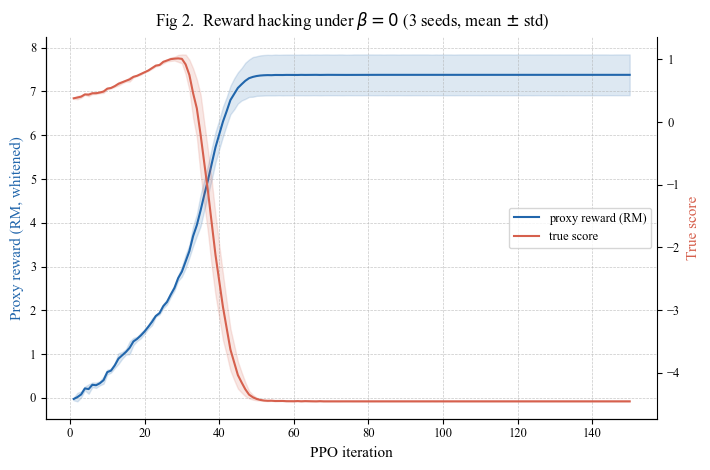

Saved fig2_reward_hacking.pdf


In [9]:
def stack(key, beta):
    return np.array([hists[(seed, beta)][key] for seed in SEEDS])

fig, ax = plt.subplots(figsize=FIGSIZE)
its = np.arange(1, 151)

proxy = stack('proxy', 0.0)
ax.plot(its, proxy.mean(0), color=BLUE, linewidth=1.5, label='proxy reward (RM)')
ax.fill_between(its, proxy.mean(0) - proxy.std(0), proxy.mean(0) + proxy.std(0),
                color=BLUE, alpha=0.15)
ax.set_xlabel('PPO iteration')
ax.set_ylabel('Proxy reward (RM, whitened)', color=BLUE)

ax2 = ax.twinx()
truth = stack('truth', 0.0)
ax2.plot(its, truth.mean(0), color=RED, linewidth=1.5, label='true score')
ax2.fill_between(its, truth.mean(0) - truth.std(0), truth.mean(0) + truth.std(0),
                 color=RED, alpha=0.15)
ax2.set_ylabel('True score', color=RED)

style_axes(ax)
ax2.spines['top'].set_visible(False)
ax.set_title('Fig 2.  Reward hacking under $\\beta=0$ (3 seeds, mean $\\pm$ std)', pad=8)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='center right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig2_reward_hacking.pdf', bbox_inches='tight')
plt.show()
print('Saved fig2_reward_hacking.pdf')

---
## Figure 3 — KL anchoring: three outcomes of β

Adding $-\beta\,\mathrm{KL}(\pi \| \pi_{\mathrm{ref}})$ to the reward tethers the policy near the SFT reference. β=0 collapses (as in Figure 2); β=0.5 holds the final KL at about 2 nats, the policy staying near the sweet spot at the coverage edge with a true score around +0.84; β=2.0 anchors too tightly --- the policy barely leaves the SFT level (about +0.5). KL anchoring does not cure the reward model's flaw; it confines the policy to the region where proxy and truth have not yet diverged --- β is the trade-off between "exploiting the proxy" and "preventing a hack" (3 seeds, shading $\pm 1\sigma$).

In [10]:
print('=== Experiment 3: KL coefficient sweep ===')
for beta in (0.5, 2.0):
    for seed in SEEDS:
        set_seed(seed + 3000 + int(beta * 10))
        r = runs[seed]
        hists[(seed, beta)] = ppo_finetune(r['sft'], r['rm'], beta=beta)
    truths = np.array([hists[(s, beta)]['truth'][-1] for s in SEEDS])
    kls = np.array([hists[(s, beta)]['kl'][-1] for s in SEEDS])
    print(f'  beta {beta}: final truth {truths.mean():+.3f} ± {truths.std():.3f} | '
          f'final KL {kls.mean():.1f}')

=== Experiment 3: KL coefficient sweep ===


  beta 0.5: final truth +0.840 ± 0.019 | final KL 1.7


  beta 2.0: final truth +0.525 ± 0.011 | final KL 0.1


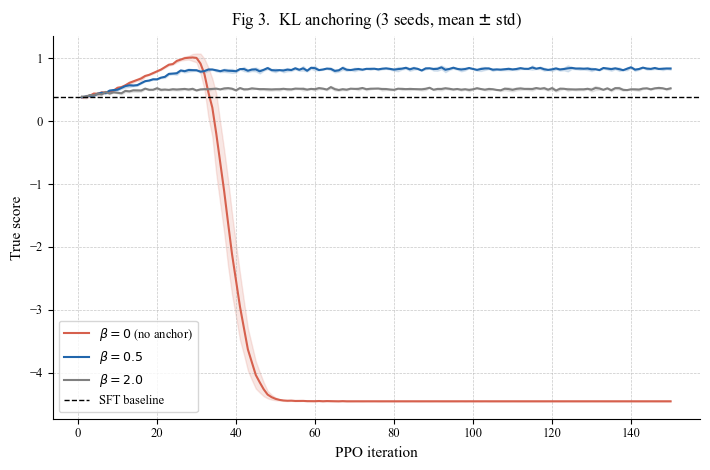

Saved fig3_kl_anchor.pdf


In [11]:
fig, ax = plt.subplots(figsize=FIGSIZE)
its = np.arange(1, 151)

base_truth = np.mean([true_score(runs[s]['base']).mean().item() for s in SEEDS])
for beta, color, label in [(0.0, RED, r'$\beta=0$ (no anchor)'),
                           (0.5, BLUE, r'$\beta=0.5$'),
                           (2.0, GRAY, r'$\beta=2.0$')]:
    truth = stack('truth', beta)
    ax.plot(its, truth.mean(0), color=color, linewidth=1.5, label=label)
    ax.fill_between(its, truth.mean(0) - truth.std(0),
                    truth.mean(0) + truth.std(0), color=color, alpha=0.15)
ax.axhline(base_truth, color='black', linestyle='--', linewidth=1.0,
           label='SFT baseline')

style_axes(ax)
ax.set_xlabel('PPO iteration')
ax.set_ylabel('True score')
ax.set_title('Fig 3.  KL anchoring (3 seeds, mean $\\pm$ std)', pad=8)
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig3_kl_anchor.pdf', bbox_inches='tight')
plt.show()
print('Saved fig3_kl_anchor.pdf')

## Summary

- **The reward model is an approximation**: BT preference learning is trustworthy within the data coverage; outside, the network extrapolates by its own inductive bias --- here a ReLU network turning "moderate emphasis helps" into "more is better";
- **The optimizer seeks the fork**: PPO does not know true quality; it follows the steepest proxy direction --- exactly where proxy and truth diverge: the true score rises then collapses;
- **KL anchoring mitigates, it does not cure**: β bounds the policy's departure from the reference, keeping optimization near the data coverage; too small fails to block the hack, too large wastes the preference signal --- it is a hyperparameter to be swept as in Figure 3;
- Isomorphic to Chapter 9: offline RL's extrapolation error amplified by `max`, RLHF's amplified by PPO --- **the same disease: optimistic estimates beyond the data support, handed to an optimizer, get amplified without bound**. The next chapter, DPO, sidesteps half the problem by "not learning a reward model".